## **1. Video I/O & Detection Basics**
`Goal: read a video frame-by-frame and detect objects (cells) in each frame.`

#### 1.1 Setup

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#### 1.2 Load video, read one frame

In [10]:
video_path = "assets/CellVideo.avi"
cap = cv2.VideoCapture(video_path)

In [11]:
ret, frame = cap.read()
print(frame.shape, cap.get(cv2.CAP_PROP_FRAME_COUNT))

(155, 192, 3) 300.0


(np.float64(-0.5), np.float64(191.5), np.float64(154.5), np.float64(-0.5))

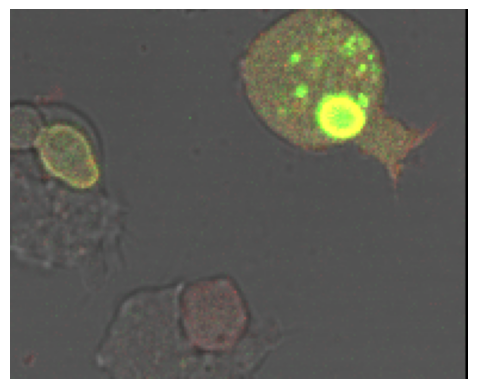

In [12]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")

## 1.3 Color-based segmentation (thresholding)
Same idea as MATLAB's Color Thresholder app in `detectCells.m`.

In [13]:
# BGR channel ranges — tune per video
lower = np.array([0, 175, 0])
upper = np.array([255, 255, 255])
mask = cv2.inRange(frame, lower, upper)

(np.float64(-0.5), np.float64(191.5), np.float64(154.5), np.float64(-0.5))

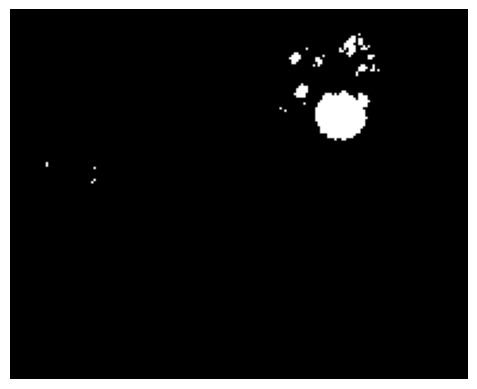

In [14]:
plt.imshow(mask, cmap="gray")
plt.axis("off")

## 1.4 Morphological cleanup

In [15]:
# close small holes inside blobs
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))

In [16]:
# erode to separate touching blobs
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mask_clean = cv2.erode(mask, kernel)

(np.float64(-0.5), np.float64(191.5), np.float64(154.5), np.float64(-0.5))

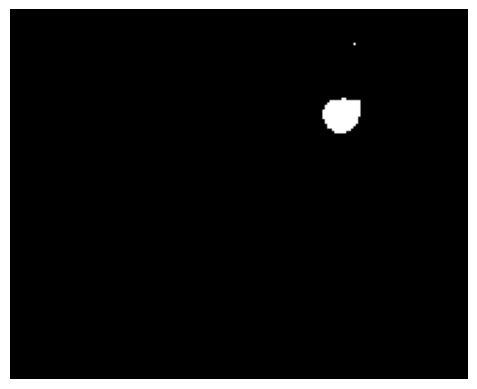

In [17]:
plt.imshow(mask_clean, cmap="gray")
plt.axis("off")

## 1.5 Contours & area filtering

In [18]:
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("raw contours:", len(contours))

raw contours: 2


In [19]:
# keep only cell-sized blobs (same range as detectCells.m: 50-400)
min_area, max_area = 50, 400
good = [c for c in contours if min_area < cv2.contourArea(c) < max_area]
print("filtered:", len(good))

filtered: 1


## 1.6 Centroids & bounding boxes

In [20]:
def get_centroid(c):
    M = cv2.moments(c)
    if M["m00"] == 0:
        return None
    return (M["m10"] / M["m00"], M["m01"] / M["m00"])

In [21]:
centroids = [get_centroid(c) for c in good]
boxes = [cv2.boundingRect(c) for c in good]

(np.float64(-0.5), np.float64(191.5), np.float64(154.5), np.float64(-0.5))

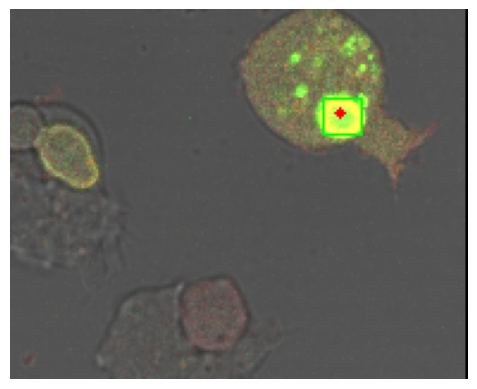

In [22]:
vis = frame.copy()
for (x, y, w, h) in boxes:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 1)
for c in centroids:
    cv2.circle(vis, (int(c[0]), int(c[1])), 2, (0, 0, 255), -1)
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")

## 1.7 Wrap it into one function
This is the Python equivalent of `detectCells.m` — used in notebooks 2 and 3.

In [26]:
def detect_objects(frame, lower, upper, area_range=(50, 400)):
    mask = cv2.inRange(frame, lower, upper)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    mask = cv2.erode(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    good = [c for c in contours if area_range[0] < cv2.contourArea(c) < area_range[1]]
    centroids = [get_centroid(c) for c in good]
    boxes = [cv2.boundingRect(c) for c in good]
    return centroids, boxes

In [24]:
c, b = detect_objects(frame, lower, upper)
print(len(c), "objects detected")

1 objects detected


In [25]:
cap.release()